# Solution 2.6: Loading, Inspecting and Cleaning (Angola IEA)

`IEA_2025_IV_TRIM_IND.sav`: the Inquerito ao Emprego em Angola, 4th quarter 2025,
published by INE Angola. 53,353 people, 206 columns, labels in Portuguese.

You will practice: reading the codebook to choose columns, renaming them to
something readable, loading with value labels, recasting what the labels got
wrong, and measuring what is missing.

**PT:** `IEA_2025_IV_TRIM_IND.sav`: Inquerito ao Emprego em Angola, IV trimestre
2025, publicado pelo INE Angola. 53.353 pessoas, 206 colunas, etiquetas em
portugues.

Vai praticar: ler o dicionario de variaveis para escolher colunas, renomea-las
para algo legivel, carregar com etiquetas de valores, corrigir os tipos que as
etiquetas estragaram, e medir o que esta em falta.

> **Pipeline:** reads `0_raw/`, writes `10_cleaned/`.

### Path Setup (run first)

Define the country folder once, then join sub folder and file name onto it.

**PT:** Defina a pasta do pais uma vez e depois junte a subpasta e o nome do
ficheiro.

In [ ]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Country folder first, then join onwards
# Primeiro a pasta do pais, depois juntar o resto
DATA_RAW_DIR = '../../data/0_raw'
DATA_CLEAN_DIR = '../../data/10_cleaned'

EMPLOYMENT_DIR = 'employment_survey'
RAW_FILE = 'IEA_2025_IV_TRIM_IND.sav'
raw_path = os.path.join(DATA_RAW_DIR, EMPLOYMENT_DIR, RAW_FILE)

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
print('Data path:', raw_path)
print('Exists?:', os.path.exists(raw_path))

Data path: ../../data/0_raw/angola/employment_survey/IEA_2025_IV_TRIM_IND.sav
Exists?: True


---

## Task 1: Read the codebook

206 columns named `ATW_PAY` or `SRH_AVN` tell you nothing. The file carries a
description for every one, so read that first.

`pd.read_spss` does not expose these descriptions, so this cell uses `pyreadstat`
with `metadataonly=True`, which reads the header without loading any data.

> Just run this cell and the next one. They set up the codebook you will use to
> choose columns in Task 3.

**PT:** 206 colunas com nomes como `ATW_PAY` nao dizem nada. O ficheiro traz uma
descricao de cada uma. `pd.read_spss` nao da acesso a estas descricoes, por isso
esta celula usa `pyreadstat` com `metadataonly=True`, que le o cabecalho sem
carregar dados.

> Basta correr esta celula e a seguinte. Preparam o dicionario que vai usar para
> escolher colunas na Tarefa 3.

In [32]:
import pyreadstat

# Header only, no data loaded / Apenas o cabecalho, sem carregar dados
_, meta = pyreadstat.read_sav(raw_path, metadataonly=True)
codebook = meta.column_names_to_labels

print('Variables described in the file:', len(codebook))
for name in ['PROV', 'DEM_AGE', 'ATW_PAY', 'SRH_AVN']:
    print(f'{name:12s} {codebook[name][:60]}')

Variables described in the file: 206
PROV         G.01 Provincia
DEM_AGE      S02_03 Qual é a idade do(a) nome
ATW_PAY      S04_01 Nos últimos sete dias, o(a) nome trabalhou durante 1 
SRH_AVN      S06_12 Se uma oportunidade de emprego ou negócio estivesse d


---

## Task 2: Find columns by what they measure

Search the descriptions instead of guessing at names. The number of matches is
itself informative: a precise concept returns one column, a vague one returns
twenty and forces you to read.

**PT:** Pesquise nas descricoes em vez de adivinhar nomes. O numero de
resultados ja e informativo: um conceito preciso devolve uma coluna, um conceito
vago devolve vinte e obriga a ler.

In [33]:
def find_columns(codebook, keyword):
    """Columns whose description contains `keyword`, case insensitive.

    Colunas cuja descricao contem `keyword`, ignorando maiusculas.
    """
    return {name: label for name, label in codebook.items()
            if label and keyword.lower() in label.lower()}


for keyword in ['sexo', 'idade', 'provincia', 'horas']:
    print(f'{keyword:12s} {len(find_columns(codebook, keyword)):3d} matches')

sexo           1 matches
idade         22 matches
provincia      1 matches
horas         29 matches


In [34]:
# A vague keyword needs reading, not trusting
# Uma palavra vaga precisa de ser lida, nao de confianca cega
for name, label in find_columns(codebook, 'idade').items():
    print(f'{name:16s} {label[:70]}')

G_13             G.13 Número de Pessoas de 15+ anos de idade
S01_07           S01_05 O nome possui bilhete de identidade (BI)
DEM_AGE          S02_03 Qual é a idade do(a) nome
MIG_CTZ          S02_09 O(a) nome tem nacionalidade angolana
MIG_CTZ_CNTY     S02_10 Diga-me a nacionalidade do nome
DEM_TRN          S03_08 Além da escola, nas últimas 4 semanas, (você/nome) participou d
RSP_AVAIL        Disponibilidade do inquirido seleccionado para ser entrevistado
ATW_PAY          S04_01 Nos últimos sete dias, o(a) nome trabalhou durante 1 ou mais ho
ATW_PFT          S04_02 Nos últimos sete dias, o(a) nome trabalhou por conta própria, d
MJU_MAC          S05_12 Qual é a actividade principal do local onde o(a) nome exerce o 
MJU_PLC          S05_14 Em que local o(a) nome realiza a sua actividade principal?
MCD_CONMIN       S05_24 O contrato garante uma quantidade mínima de horas ou trabalho p
MJD_SINGLE_CLIENT S05_29 Mais da metade da receita do negócio/atividade vem de …?
MJD_SELL_CLIENT  S05_

**Answers:**

- `sexo` and `provincia` match one column each. `idade` matches 22 and `horas`
  29, because those words appear inside long question texts about other things.
- Of the 22 `idade` matches only `DEM_AGE` is the respondent's own age. `G_13`
  counts household members aged 15 or more, a different variable entirely.
- Searching the codebook narrows 206 columns to a handful you then read properly.

**PT:** `sexo` e `provincia` devolvem uma coluna cada. `idade` devolve 22 e
`horas` 29, porque essas palavras aparecem dentro de perguntas sobre outras
coisas. Das 22, so `DEM_AGE` e a idade do proprio inquirido. Pesquisar o
dicionario reduz 206 colunas a um punhado que depois se le com atencao.

---

## Task 3: Select the columns and give them readable names

The questionnaire's names are precise and unreadable. `SRH_AVN` is correct and
tells you nothing; `available_last_week` tells you what it holds.

Rename once, here, and every later line of code is easier to check. The mapping
is the bridge back to the official codebook, so it gets saved in Task 4 rather
than living only in this notebook.

**PT:** Os nomes do questionario sao precisos e ilegiveis. `SRH_AVN` esta certo e
nao diz nada; `available_last_week` diz o que contem.

Renomeie uma vez, aqui, e todas as linhas seguintes ficam mais faceis de
verificar. O mapeamento e a ponte de volta ao dicionario oficial, por isso e
gravado na Tarefa 4.

In [35]:
# Questionnaire name -> readable name / Nome do questionario -> nome legivel
RENAME_MAP = {
    'NIDF': 'household_id',
    'PPNO': 'person_id',
    'G_06_ID_IEA': 'cluster_id',
    'PROV': 'province',
    'AREA_RESID': 'area_type',
    'G_15_TRIMESTRE': 'quarter',
    'DEM_REL': 'relation_to_head',
    'DEM_SEX': 'sex',
    'DEM_AGE': 'age',
    'DEM_MRT': 'marital_status',
    'DEM_EDL': 'education_level',
    'S03_01': 'attended_school',
    'ATW_PAY': 'worked_for_pay',
    'ATW_PFT': 'worked_own_account',
    'ATW_FAM': 'worked_family_business',
    'ABS_JOB': 'absent_from_job',
    'SRH_JOB': 'sought_job',
    'SRH_BUS': 'sought_business',
    'SRH_AVN': 'available_last_week',
    'SRH_AVL': 'available_next_2weeks',
    'SRH_DES': 'wants_work',
    'WKT_USHRSTOT': 'usual_hours',
    'WKT_ACHRSTOT': 'actual_hours',
    'MJT_SYR': 'job_start_year',
    'MJJ_EMP_REL': 'employment_relation',
    'GHVEDT': 'interview_date',
    'POND_IEA_IV_TRIM_2025_IND': 'weight',
}

SPSS_COLS = list(RENAME_MAP)
print('Selected:', len(SPSS_COLS), 'of', len(codebook))

Selected: 27 of 206


**Answers:**

- 27 of 206. `G_12` and `G_13` are deliberately absent: they are empty in every
  row of this extract, so there is no reason to load them.
- One dictionary does two jobs: its keys are the columns to load, its values the
  names to use afterwards, so the two can never drift apart.
- Renaming is a convenience with a cost: `available_last_week` no longer matches
  anything in INE's documentation. Task 4 saves the mapping so the link survives.

**PT:** 27 de 206. `G_12` e `G_13` ficam de fora porque estao vazias em todas as
linhas. Um dicionario faz duas coisas: as chaves sao as colunas a carregar, os
valores os nomes a usar. Renomear tem um custo: `available_last_week` ja nao
corresponde a nada na documentacao do INE, por isso a Tarefa 4 grava o
mapeamento.

---

## Task 4: Load, rename, and save the codebook

`pd.read_spss` applies the file's value labels by default, so coded variables
arrive as readable Portuguese text.

Then save the three way mapping, original name, new name and description, as its
own small file. Six months from now it is the only thing that will tell you what
`wants_work` was called and what question produced it.

**PT:** `pd.read_spss` aplica as etiquetas de valores por omissao, por isso as
variaveis codificadas chegam como texto legivel em portugues.

Depois grave o mapeamento de tres colunas, nome original, nome novo e descricao,
num ficheiro proprio. Daqui a seis meses e a unica coisa que lhe dira como se
chamava `wants_work` e que pergunta a produziu.

In [36]:
df = pd.read_spss(raw_path, usecols=SPSS_COLS)
df = df.rename(columns=RENAME_MAP)

print('Loaded:', df.shape)
df.head()

Loaded: (53353, 27)


,household_id,cluster_id,province,relation_to_head,area_type,quarter,sex,person_id,age,marital_status,...,job_start_year,usual_hours,actual_hours,sought_job,sought_business,wants_work,available_last_week,available_next_2weeks,interview_date,weight
0,"9,250,068.00",925.00,Namibe,Cônjuge,Urbana,IVº Trimestre,Feminino,2.00,45.00,União de facto,...,"2,022.00",66.00,66.00,NaN,NaN,NaN,NaN,NaN,"20,251,204.00",322.02
1,"12,870,026.00","1,287.00",Cuando,Neto(a),Rural,IVº Trimestre,Masculino,9.00,7.00,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,171.30
2,"4,600,048.00",460.00,Cuanza-Sul,Filho (a),Rural,IVº Trimestre,Masculino,2.00,15.00,Solteiro/Nunca viveu em união de facto,...,NaN,NaN,NaN,Não,Não,Sim,Sim,NaN,"20,251,212.00","1,010.98"
3,"4,600,023.00",460.00,Cuanza-Sul,Chefe/Pessoa de referência,Rural,IVº Trimestre,Masculino,1.00,30.00,União de facto,...,NaN,NaN,NaN,Não,Não,Não,NaN,NaN,"20,251,212.00",999.80
4,"4,790,052.00",479.00,Cuanza-Sul,Chefe/Pessoa de referência,Rural,IVº Trimestre,Masculino,1.00,37.00,União de facto,...,"1,998.00",30.00,30.00,NaN,NaN,NaN,NaN,NaN,"20,251,216.00","1,011.64"


In [37]:
# Keep the bridge back to the official documentation
# Guardar a ponte de volta a documentacao oficial
codebook_df = pd.DataFrame({
    'original_name': SPSS_COLS,
    'new_name': [RENAME_MAP[name] for name in SPSS_COLS],
    'description': [codebook[name] for name in SPSS_COLS],
})

os.makedirs(DATA_CLEAN_DIR, exist_ok=True)
codebook_path = os.path.join(DATA_CLEAN_DIR, 'angola_iea_2025q4_codebook.csv')
codebook_df.to_csv(codebook_path, index=False)

print('Saved:', codebook_path)
codebook_df.head(8)

Saved: ../../data/10_cleaned/angola_iea_2025q4_codebook.csv


,original_name,new_name,description
0,NIDF,household_id,NaN
1,PPNO,person_id,Número da pessoa
2,G_06_ID_IEA,cluster_id,G.06 Número do Conglomerado (ID. IEA)
3,PROV,province,G.01 Provincia
4,AREA_RESID,area_type,G.05_Área de Residência
5,G_15_TRIMESTRE,quarter,G.15 Trimestre
6,DEM_REL,relation_to_head,S01_02 Qual é a relação de parentesco entre o(...
7,DEM_SEX,sex,S02_01 Qual é o sexo do(a) nome


**Answers:**

- 53,353 rows and 27 columns, one row per person.
- `province`, `area_type` and `sex` arrive as readable text (`Luanda`, `Urbana`,
  `Feminino`) rather than the numeric codes stored in the file.
- The codebook file is small and boring and will save somebody hours. It is the
  only artefact that survives the rename, because the CSV of data carries names
  with no explanation attached.

**PT:** 53.353 linhas e 27 colunas, uma por pessoa. `province`, `area_type` e
`sex` chegam como texto legivel em vez dos codigos numericos. O ficheiro de
dicionario e pequeno e aborrecido e vai poupar horas a alguem: e o unico artefacto
que sobrevive a mudanca de nomes.

---

## Task 5: Summary statistics

Look hard at every `min` and `max`, and at any `count` below 53,353.

**PT:** Olhe com atencao para cada `min` e `max`, e para qualquer `count` abaixo
de 53.353.

In [38]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
household_id,"53,353.00",NaN,NaN,NaN,"6,623,692.70","3,718,875.63","10,005.00","3,440,107.00","6,690,016.00","9,810,016.00","13,080,051.00"
cluster_id,"53,353.00",NaN,NaN,NaN,662.36,371.89,1.00,344.00,669.00,981.00,"1,308.00"
province,53353,21,Luanda,4424,NaN,NaN,NaN,NaN,NaN,NaN,NaN
relation_to_head,53352,11,Filho (a),27164,NaN,NaN,NaN,NaN,NaN,NaN,NaN
area_type,53353,2,Urbana,34173,NaN,NaN,NaN,NaN,NaN,NaN,NaN
quarter,53353,1,IVº Trimestre,53353,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,53353,2,Feminino,27752,NaN,NaN,NaN,NaN,NaN,NaN,NaN
person_id,"53,353.00",NaN,NaN,NaN,3.31,2.18,1.00,2.00,3.00,5.00,20.00
age,"53,353.00",NaN,NaN,NaN,21.89,18.10,0.00,8.00,17.00,32.00,120.00
marital_status,32861,6,União de facto,13777,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Answers:**

- `usual_hours` and `actual_hours` max out at 997. Nobody works 997 hours in a
  week, so that is a code standing in for an answer, not a measurement.
- `age` runs 0 to 120. Age 0 is legitimate, 1,532 infants. Age 120 is not.
- `interview_date` has a mean around 20,251,000, nonsense as a number because it
  is really a date written as the digits `20251204`.
- The `count` row exposes the skip pattern: the labour columns are answered by
  about a fifth of the sample.

**PT:** `usual_hours` e `actual_hours` chegam a 997: e um codigo, nao uma medida.
`age` vai de 0 a 120; 0 e legitimo, 120 nao. `interview_date` e uma data escrita
como digitos. A linha `count` revela os saltos do questionario.

---

## Task 6: Explore categories

`value_counts()` shows what is actually in a coded column. Always pass
`dropna=False`. A bar plot makes the shape obvious at a glance.

**PT:** `value_counts()` mostra o que esta realmente numa coluna codificada. Use
sempre `dropna=False`. Um grafico de barras torna a forma imediata.

In [39]:
print(df['province'].value_counts(dropna=False).sort_index())

province
Bengo            2235
Benguela         2476
Bié              2422
Cabinda          2305
Cuando           1498
Cuanza-Norte     2676
Cuanza-Sul       2530
Cubango          2309
Cunene           2694
Huambo           2797
Huila            2837
Icolo e Bengo    2889
Luanda           4424
Lunda-Norte      2067
Lunda-Sul        2914
Malanje          2332
Moxico           1782
Moxico Leste     2123
Namibe           3108
Uíge             3029
Zaire            1906
Name: count, dtype: int64


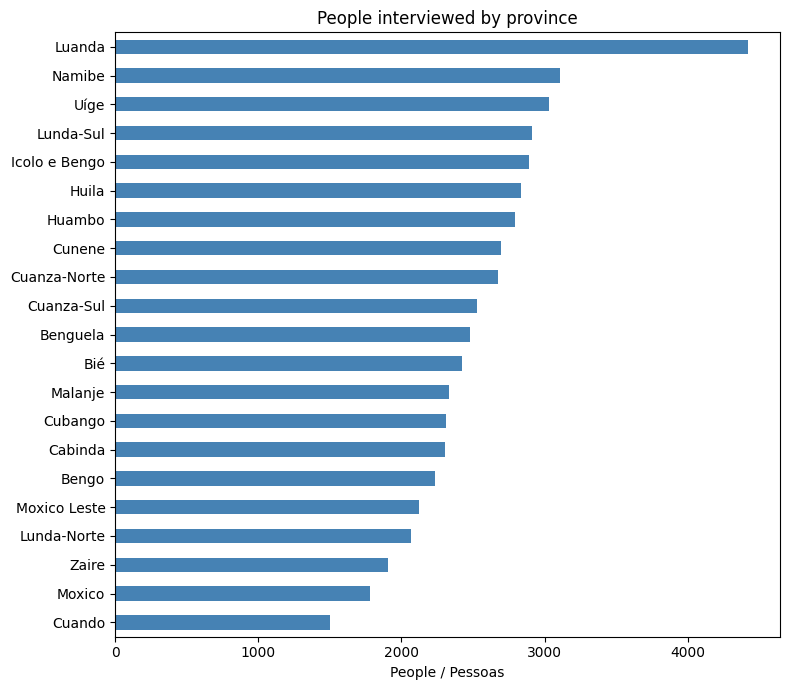

In [40]:
# Sort before plotting so the bars carry the ranking
# Ordenar antes de desenhar para que as barras mostrem o ranking
df['province'].value_counts().sort_values().plot(
    kind='barh', figsize=(8, 7), color='steelblue')
plt.title('People interviewed by province')
plt.xlabel('People / Pessoas')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [41]:
print(df['area_type'].value_counts(dropna=False))
print()
print(df['sex'].value_counts(dropna=False))
print()
print('Distinct households:', df['household_id'].nunique())
print(df['household_id'].value_counts().describe())

area_type
Urbana    34173
Rural     19180
Name: count, dtype: int64

sex
Feminino     27752
Masculino    25601
Name: count, dtype: int64

Distinct households: 13036
count   13,036.00
mean         4.09
std          2.47
min          1.00
25%          2.00
50%          4.00
75%          6.00
max         20.00
Name: count, dtype: float64


**Answers:**

- All 21 provinces appear, Luanda largest at 4,424. Icolo e Bengo, Moxico Leste
  and Cuando were created in 2024, so any older reference table will not know
  them.
- The bar plot shows the sample is spread deliberately rather than by population:
  Luanda is the largest but nothing like 4,424 against 1,498 would suggest if
  these were population shares. That is the survey design, and it is why the
  weight column exists.
- 34,173 urban and 19,180 rural; 25,601 male and 27,752 female.
- 13,036 households across 53,353 people, a mean of 4.09 each.

**PT:** Aparecem as 21 provincias, Luanda a maior com 4.424. Icolo e Bengo,
Moxico Leste e Cuando foram criadas em 2024. O grafico mostra que a amostra e
distribuida por desenho e nao por populacao, e por isso existe a coluna de
ponderador. 13.036 agregados para 53.353 pessoas, media de 4,09.

---

## Task 7: Read the dtypes critically

The dtypes decide the next hour of work.

**PT:** Os tipos de dados determinam a proxima hora de trabalho.

In [42]:
print(type(df))
print(type(df['age']))

<class 'pandas.DataFrame'>
<class 'pandas.Series'>


In [43]:
df.dtypes

household_id               float64
cluster_id                 float64
province                  category
relation_to_head          category
area_type                 category
quarter                   category
sex                       category
person_id                  float64
age                        float64
marital_status            category
attended_school           category
education_level           category
worked_for_pay            category
worked_own_account        category
worked_family_business    category
absent_from_job           category
employment_relation       category
job_start_year            category
usual_hours                float64
actual_hours               float64
sought_job                category
sought_business           category
wants_work                category
available_last_week       category
available_next_2weeks     category
interview_date             float64
weight                     float64
dtype: object

**Answers:**

- Labelled columns are `category`, the rest `float64`.
- Three are wrong for what the column means: `household_id`, `person_id` and
  `cluster_id` are identifiers arriving as floats with a trailing `.0`;
  `interview_date` is a date in a float; `job_start_year` is a **year** that came
  back as `category`.

**PT:** As colunas com etiquetas sao `category`, as restantes `float64`. Tres
estao erradas: os identificadores chegam como float com `.0` no fim,
`interview_date` e uma data dentro de um float, e `job_start_year` e um **ano**
que veio como `category`.

---

## Task 8: Recast what the file got wrong

`job_start_year` is the year somebody started their main job, and it arrived as a
category. Look at its categories to see why: alongside the years there is a text
label, so pandas concluded the whole column was categorical. A year you cannot
subtract is useless.

`pd.to_numeric` with `errors='coerce'` fixes it in one move: real years convert,
the text label becomes `NaN`. A year is a whole number, so store it as a nullable
integer, and summarise it with the median rather than the mean, since a year has
no meaningful average once part of the column is unknown.

**PT:** `job_start_year` e o ano em que a pessoa comecou o emprego principal, e
chegou como categoria. Veja as categorias: alem dos anos ha uma etiqueta de
texto, por isso o pandas tornou a coluna categorica. Um ano que nao se pode
subtrair nao serve.

`pd.to_numeric` com `errors='coerce'` resolve: os anos reais convertem, a
etiqueta vira `NaN`. Um ano e um numero inteiro, entao guarde como inteiro que
aceita nulos, e resuma com a mediana em vez da media.

In [44]:
# What is in there besides years? / O que ha alem de anos?
print([c for c in df['job_start_year'].cat.categories if not isinstance(c, float)])

['NÃO SABE']


In [45]:
df['job_start_year'] = (
    pd.to_numeric(df['job_start_year'].astype('object'), errors='coerce')
    .astype('Int64')
)

print('dtype:  ', df['job_start_year'].dtype)
print('range:  ', df['job_start_year'].min(), 'to', df['job_start_year'].max())
print('median: ', df['job_start_year'].median())
print('unknown:', df['job_start_year'].isna().sum())

dtype:   Int64
range:   1965 to 2025
median:  2020.0
unknown: 43389


In [46]:
# The hours columns kept the same kind of code, but with no label attached,
# so they stayed numeric and it has to go by hand.
# As colunas de horas mantiveram o mesmo tipo de codigo, mas sem etiqueta,
# por isso continuam numericas e tem de ser tratadas a mao.
print('hours max before:', df['usual_hours'].max())

df['usual_hours'] = df['usual_hours'].replace([997, 998, 999], np.nan)
df['actual_hours'] = df['actual_hours'].replace([997, 998, 999], np.nan)

print('hours max after: ', df['usual_hours'].max())

hours max before: 997.0
hours max after:  120.0


In [47]:
# Identifiers are labels, not quantities: float to integer to string, or the
# trailing .0 survives and joins to nothing.
# Identificadores sao etiquetas, nao quantidades: float para inteiro para texto.
print('Before:', df['household_id'].head(3).tolist())

for col in ['household_id', 'person_id', 'cluster_id']:
    df[col] = df[col].astype('int64').astype('string')

print('After: ', df['household_id'].head(3).tolist())

Before: [9250068.0, 12870026.0, 4600048.0]
After:  ['9250068', '12870026', '4600048']


In [48]:
# interview_date is the float 20251204.0. Int64 tolerates the missing values.
# interview_date e o float 20251204.0. Int64 aceita os valores em falta.
df['interview_date'] = pd.to_datetime(
    df['interview_date'].astype('Int64').astype('string'),
    format='%Y%m%d', errors='raise')

print('dtype:', df['interview_date'].dtype)
print('Range:', df['interview_date'].min(), 'to', df['interview_date'].max())
print()
print(df['interview_date'].dt.month.value_counts(dropna=False).sort_index())

dtype: datetime64[us]
Range: 2024-11-10 00:00:00 to 2026-01-28 00:00:00

interview_date
1.00       553
11.00     9029
12.00    20100
NaN      23671
Name: count, dtype: int64


**Answers:**

- The only non year category is a text label meaning "does not know", which is
  what forced the whole column to be categorical.
- After the cast `job_start_year` is `Int64`, running 1965 to 2025 with a median
  of 2020 and 43,382 unknown. The median is the honest summary: a mean over years
  invites the reader to treat it as a date, and it is not one.
- `usual_hours` drops from 997 to 120 once the codes are replaced.
- Without the `int64` step the identifier reads `'9250068.0'` and matches nothing.
- The date range is **2024-11-10 to 2026-01-28**, both ends impossible for a 4th
  quarter file. 9,026 interviews fall in November 2025 and 20,100 in December,
  553 in January 2026 and 3 in November 2024. Not one is dated October, which for
  a quarter running October to December is worth raising with the producer.

**PT:** A unica categoria que nao e um ano e uma etiqueta de texto que significa
"nao sabe". Depois da conversao, `job_start_year` e `Int64`, de 1965 a 2025, com
mediana de 2020 e 43.382 desconhecidos. A mediana e o resumo honesto. As horas
descem de 997 para 120. Sem o passo `int64` o identificador fica `'9250068.0'`. O
intervalo de datas vai de 2024-11-10 a 2026-01-28, e nenhuma entrevista tem data
de outubro, o que num IV trimestre merece ser reportado ao produtor.

---

## Task 9: Detect missing values

Count them, express them as a share, and look at the shape before deciding
anything.

**PT:** Conte, converta em percentagem, e observe o padrao antes de decidir.

In [49]:
missing = pd.DataFrame({
    'n_missing': df.isna().sum(),
    'pct_missing': (df.isna().mean() * 100).round(1),
})
missing.sort_values('pct_missing', ascending=False)

,n_missing,pct_missing
available_next_2weeks,52539,98.50
job_start_year,43389,81.30
available_last_week,43049,80.70
absent_from_job,42761,80.10
actual_hours,41725,78.20
usual_hours,41719,78.20
employment_relation,41716,78.20
worked_family_business,39090,73.30
wants_work,38305,71.80
sought_business,37547,70.40


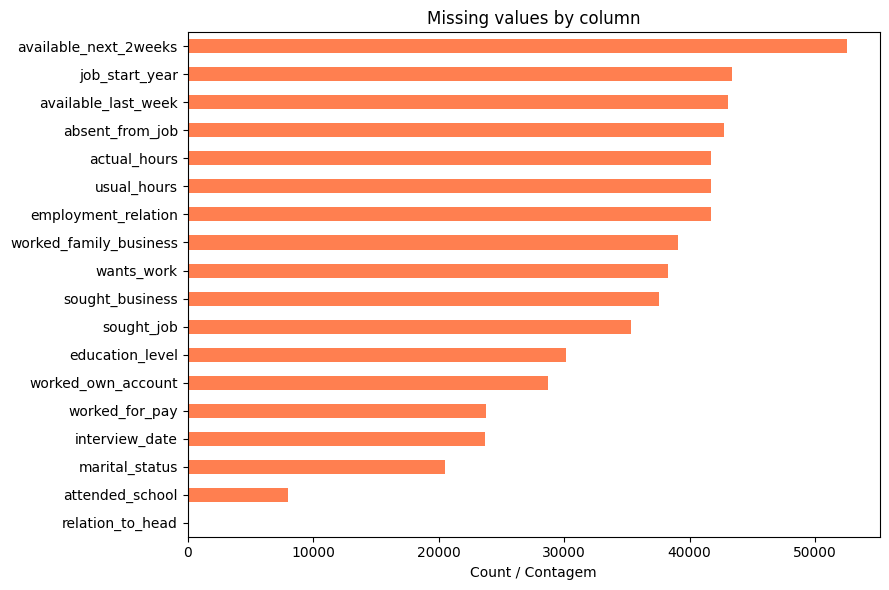

In [50]:
counts = df.isna().sum()
counts[counts > 0].sort_values().plot(kind='barh', color='coral', figsize=(9, 6))
plt.title('Missing values by column')
plt.xlabel('Count / Contagem')
plt.tight_layout()
plt.show()

**Answers:**

- A large block sits between 44% and 98.5% missing, and almost none of it is
  damage.
- The heavily missing group is the labour module: only people routed into it
  answer. `available_next_2weeks` is 98.5% missing because it is asked only of
  those who said no to `available_last_week`.
- Missing by design and missing by error need opposite treatment, so `dropna()`
  here would be a catastrophe: no single person answered every module.
- Check the codebook file for any column you are unsure about. The question text
  usually explains the gap.

**PT:** Um grande bloco esta entre 44% e 98,5% em falta, e quase nada disso e
dano. O grupo mais vazio e o modulo de trabalho: so responde quem o questionario
encaminha para la. `available_next_2weeks` esta 98,5% vazia porque so e
perguntada a quem disse nao a `available_last_week`. Falta por desenho e falta
por erro exigem tratamentos opostos.

---

## Task 10: Save

Raw data is read only. Write to `10_cleaned/` and reload to confirm the round
trip.

**PT:** Os dados brutos sao apenas de leitura. Grave em `10_cleaned/` e
recarregue para confirmar.

In [51]:
out_path = os.path.join(DATA_CLEAN_DIR, 'angola_iea_2025q4_clean.csv')

df.to_csv(out_path, index=False)
print('Saved:', out_path, '|', df.shape)

Saved: ../../data/10_cleaned/angola_iea_2025q4_clean.csv | (53353, 27)


In [52]:
check = pd.read_csv(out_path, dtype={'household_id': 'string',
                                     'person_id': 'string',
                                     'cluster_id': 'string'})
print('Reloaded:', check.shape)
print(check[['household_id', 'province', 'interview_date', 'job_start_year']].dtypes)

Reloaded: (53353, 27)
household_id       string
province              str
interview_date        str
job_start_year    float64
dtype: object


**Answers:**

- 53,353 rows by 27 columns. Nothing was removed: this notebook fixed types and
  measured what is missing, it did not decide what to discard.
- `interview_date` reloads as text, `province` as text rather than `category`, and
  `job_start_year` as float rather than `Int64`. CSV stores no dtypes, so every
  reader re-establishes them.
- That is exactly why the codebook file written in Task 4 matters: it is the only
  part of this work that survives the round trip intact.

**PT:** 53.353 linhas por 27 colunas. Nada foi removido: este caderno corrigiu
tipos e mediu o que falta, nao decidiu o que descartar. Ao recarregar, os tipos
perdem-se, porque o CSV nao guarda tipos. E por isso que o ficheiro de dicionario
da Tarefa 4 importa: e a unica parte deste trabalho que sobrevive intacta.